# How does winner takes all work under the hood?

## Introduction  

In this notebook, we aim to lay the groundwork for implementing the reward function in this Bittensor subnet. At its core, the optimisation goal is to minimise the average error between the miner's prediction and the actual measured environmental values. To ensure positive and negative errors don't cancel out, an intuitive measure would be to minimise the Root Mean Squared Error (RMSE), we also include the Mean Absolute Error (MAE).

### Winner takes all implementation

A single challenge (i.e. request to the miners) consists of 48 hours (in step of 1 hour) for a single variable across all locations on earth on the ERA5 0.25 degree grid. 
Therefore, a single request is for 49 distinct datetimes, for 721x1440 locations. Every day four requests are made, at 12AM, 6AM, 12PM, and 6PM, for the next 48 hours (including now (step 0) and hour 48 (step 17)).

With this new setup, due to the large size of the prediction, a new compression function is introduced. To account for possible failure of transferring the information, we allow miners 3 strikes. Meaning that, if a miner doesn't respond on the first request, it is queried again, up to two more times. If no response was recorded for a given miner, the RMSE of those "bad" miners is set to infinity. 

Once all the miners have responded, or are out of strikes, and 7 days have passed since the request, a challenge is scored. The reason for waiting 7 days is that ERA5 data is released with 5 day delay, and to score a challenge, we need ground truth data for the last step to be released.

A challenge is scored by calculating the area-weighted RMSE and MAE for every miner's prediciton against the ERA5 ground truth. The miners are ranked based on their RMSEs and MAEs, the one with the lowest average error gets the highest rank.

A history of each miner's ranks across past challenges is kept. Upon scoring every challenge, the final/overall score of a miner is calculated and pushed to the metagraph. To qualify for a score, a miner must have participated in at least $C$ challenges (the window size).

For qualifying miners, an overall rank is calculated as the average of their last $C$ ranks. Miners are then sorted based on this average rank. Ties are broken by looking at the rank history in reverse chronological order (giving priority to the miner who performed better in the most recent challenge, then the second most recent, and so on). 
 
### The Reward Function  

To properly calculate the errors across the globe, we must account for the fact that grid cells near the equator cover a larger physical area than those near the poles. Therefore, we use an area-weighted RMSE and MAE, where the denominator is the sum of all weights rather than just the number of data points

$$
\text{RMSE(m)} = \sqrt{\frac{1}{N}\sum_{i=1}^N (\left(f(x_i) - y_i\right)^2) * weight_i}
$$

$$
\text{MAE(m)} = \frac{1}{N}\sum_{i=1}^N \lvert f(x_i) - y_i \rvert * weight_i
$$

For standard non-polar grid cells, the weight is proportional to the area bounded by the latitude steps:

$$
\text{weight}_i =  2 * \sin(\frac{\Delta lat}{2}) * \cos(lat_i)
$$

For the exact polar cells (where the boundary touches 90° or -90°), the formula simplifies to:

$$
\text{weight}_i =  2 * \sin ^ 2(\frac{\Delta lat}{4}) 
$$

The challenge score determines the miner's rank for that specific challenge (where a lower RMSE and MAE equals a better rank, with 1 being the best):

$$
\text{challenge\_rank}_{m, c} = \text{Rank}(\frac{\text{RMSE}_{m, c} + \text{MAE}_{m, c}}{2})
$$

The winwow size is flexible, to account for the short history miners will have upon the spinning of a new validator. 

$$
C = \min\left(10, \max_{m} \big| H_m \big| \right)
$$

The overall average rank for a miner with history length $|H_m|$ over the window size $C$ is calculated as:

$$\text{avg\_rank}_m = 
\begin{cases} 
\frac{1}{C} \sum_{c=1}^{C} \text{challenge\_rank}_{m, c}, & \text{if } |H_m| \ge C \\
\infty, & \text{if } |H_m| < C
\end{cases}
$$

After sorting the miners by $\text{avg\_rank}_m$ (with ties broken by comparing historical ranks sequentially from most recent to oldest), each miner receives a final sorted position $r$, where $r=1$ is the best miner, and $K$ is the total number of qualifying miners. 

The reward weights ($W_r$) are distributed such that a fixed percentage ($P_{winner}$) goes to the top miner, and the remainder is distributed logarithmically to the rest:

$$W_r = 
\begin{cases} 
P_{winner}, & \text{if } r = 1 \\
(1 - P_{winner}) \times \frac{\ln(K - r + 2)}{\sum_{j=2}^K \ln(K - j + 2)}, & \text{if } r > 1
\end{cases}$$


Where:  
- $N$: The total number of data points (both in time and location) the sample has.
- $C$: The number of recent challenges used to calculate the final rank
- $H_m$ as the rank history (the list of past challenge ranks) for miner $m$, where $|H_m|$ represents the length of that history.
- $f(x_i)$: The miner's prediction for time-location point $x_i$  
- $y_i$: The true ERA5 measurement at time-location $x_i$ 
- RMSE($m$): The area-weighted root mean squared error of miner $m$
- $\Delta lat$ : The grid size id degrees ($0.25\degree$ for ERA5)
- $lat_i$: the latitude at time-location point $i$ 
- $K$: The total number of valid miners with sufficient history.
- $r$: The overall sorted position of the miner.
- $P_{winner}$: The exact percentage of the total weight allocated to the 1st place miner.

### What we do in the first 7 days after the code is realised but miners can't be scored

The main issure with forecatsing the future and using ERA5 as ground trth is that we need to wait until the measurements for the last timestep of prediction becomes available to score. Therefore, in our case, we have to wait 7 days. Because we need to set weights to the miners in this period, but we don't know their actual socre, we  decided to reward active miners by giving them a small weight, while we burn 90% of the other alpha. We define an active miner as one that has reponded to at least one of the challenges we have queried. 


## Visualisation of the reward

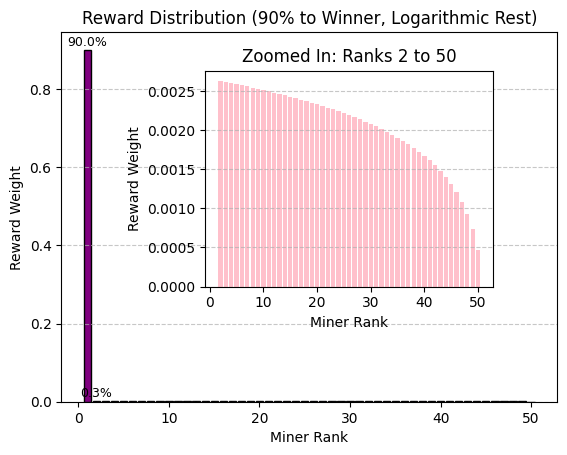

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameters
PERCENTAGE_GOING_TO_WINNER = 0.9
num_miners = 50  # We use 50 miners for a clear visualization

# Initialize arrays for ranks and weights
ranks = np.arange(1, num_miners + 1)
weights = np.zeros(num_miners)

# Winner gets 90%
weights[0] = PERCENTAGE_GOING_TO_WINNER

# Calculate the remaining weight distribution
remaining_weight = 1.0 - PERCENTAGE_GOING_TO_WINNER
n = num_miners - 1

if n > 0:
    # Logarithmic decay: log(n), log(n-1), ..., log(1)
    log_weights = [math.log(n + 1 - i) for i in range(n)]
    total_log = sum(log_weights)
    
    # Normalize and assign to ranks 2+
    for i in range(n):
        weights[i + 1] = remaining_weight * (log_weights[i] / total_log)

# --- Plotting ---
# Main plot showing the massive 90% spike for Rank 1
plt.bar(ranks, weights, color='purple', edgecolor='black')
plt.xlabel('Miner Rank')
plt.ylabel('Reward Weight')
plt.title(f'Reward Distribution ({int(PERCENTAGE_GOING_TO_WINNER*100)}% to Winner, Logarithmic Rest)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add percentage labels for the top 3 on linear scale
for i in range(2):
    plt.text(ranks[i], weights[i] + 0.002, f"{weights[i]*100:.1f}%", ha='center', va='bottom', fontsize=9)

# Inset plot to show the logarithmic decay for ranks 2 through 50 clearly
ax_inset = plt.axes([0.35, 0.35, 0.45, 0.45])
ax_inset.bar(ranks[1:], weights[1:], color='pink')
ax_inset.set_title(f'Zoomed In: Ranks 2 to {num_miners}')
ax_inset.set_xlabel('Miner Rank')
ax_inset.set_ylabel('Reward Weight')
ax_inset.grid(axis='y', linestyle='--', alpha=0.7)
# Save the visualization
# plt.savefig('Current_reward_distribution.png')

### Visualisation of the weight accounting for the grid cell area

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the latitude weights
weights = np.load("../zeus/data/weights/latitude_weights_for_rmse.npy")

# Create corresponding latitude array
delta_latitude = 0.25
latitudes = np.arange(-90, 90 + delta_latitude, delta_latitude)

print(f'Weights shape: {weights.shape}')
print(f'Weight range: [{weights.min():.4f}, {weights.max():.4f}]')
print(f'Weight mean: {weights.mean():.4f}')

Weights shape: (721,)
Weight range: [0.0009, 1.5730]
Weight mean: 1.0000


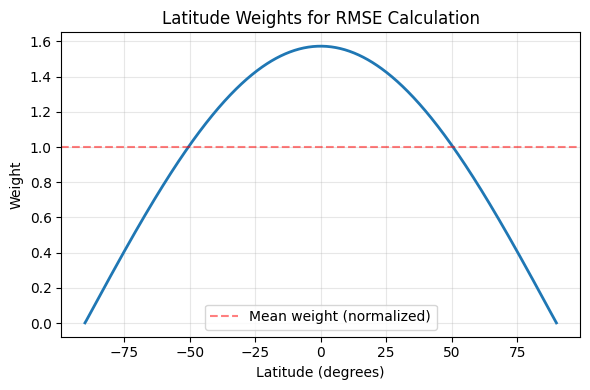

In [66]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(latitudes, weights, linewidth=2)
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Weight')
ax.set_title('Latitude Weights for RMSE Calculation')
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Mean weight (normalized)')
ax.legend()
plt.tight_layout()
plt.show()

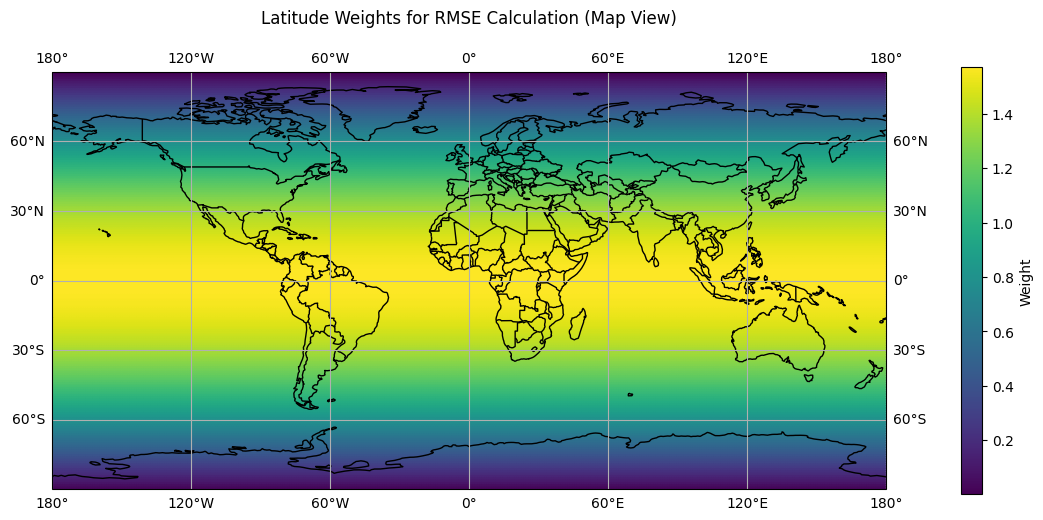

In [72]:
longitudes = np.arange(-180, 180, 0.25)  # 0.25 degree resolution
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

weight_grid = np.tile(weights[:, np.newaxis], (1, len(longitudes)))

# Plot on map
fig = plt.figure(figsize=(12.0, 10.0), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.set_axisbelow(True)

gl = ax.gridlines(draw_labels=True)

step = 4
scatterplot = ax.scatter(
    lon_grid[::step, ::step], 
    lat_grid[::step, ::step], 
    c=weight_grid[::step, ::step], 
    s=10,
    marker="o",
    lw=0,
    transform=ccrs.PlateCarree(),
    cmap='viridis'
)

cbar = fig.colorbar(scatterplot, ax=ax, fraction=0.023, pad=0.08, label='Weight')
ax.set_title('Latitude Weights for RMSE Calculation (Map View)', pad=20)
plt.show()